In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
trade_history = pd.read_csv('data/processed.csv')

## Date Based Relationship

In [3]:
# overall totals without classification
overall = trade_history.groupby(
    'day_month'
).agg({
    'Trade ID': 'count',
    'Closed PnL': ['sum', 'mean']
})

overall

Trade ID    Closed PnL            
             count           sum        mean
day_month                                   
1             3182  1.437138e+05   45.164611
2             3871  4.649395e+05  120.108379
3             6874  1.009652e+06  146.879895
4             7533  7.779073e+05  103.266604
5             4659  4.608209e+05   98.909834
6             6148  2.083146e+04    3.388332
7             8601  3.231531e+05   37.571571
8             3869  2.176832e+05   56.263431
9             7710  2.962334e+05   38.421972
10            9029  2.624246e+05   29.064635
11            7422  3.924817e+05   52.880849
12           10327  1.309124e+06  126.767081
13            5549  1.591544e+05   28.681630
14            6724  5.031004e+05   74.821588
15            4778  3.300487e+05   69.076743
16            4757  2.505900e+05   52.678163
17            5906  2.790904e+05   47.255395
18            7270  1.963790e+05   27.012244
19           11316  2.848685e+05   25.173958
20            9811  5.073455e+05   51.711906
21            8139  3.731935e+05   45.852499
22            6886  4.587318e+05   66.618037
23           12051 -2.256757e+05  -18.726721
24           10545  2.246396e+05   21.302952
25            9953  2.699138e+05   27.118842
26            7278  1.931893e+05   26.544288
27            3862  7.916450e+04   20.498318
28            4309  1.770877e+05   41.097175
29            6273  3.607782e+05   57.512859
30            3759  1.035019e+05   27.534431
31            2827  5.042042e+04   17.835308

## Key Insights: Date Based Trading Patterns

- `03` was the most profitable trading day of the month:
  - Avg PnL = **$146.88**
  - Total PnL = **$1.01M**

- `12` generated the highest total pnl overall:
  - **$1.31M total pnl**
  - Avg PnL = **$126.77**

- `02`, `04`, and `05` also showed strong profitability:
  - `02` → **$120.11 avg pnl**
  - `04` → **$103.27 avg pnl**
  - `05` → **$98.91 avg pnl**

- `23` was the only loss-making day:
  - Avg PnL = **-$18.73**
  - Total PnL = **-$225.68K**

- Highest trading activity occurred during:
  - `23` → **12,051 trades**
  - `19` → **11,316 trades**
  - `24` → **10,545 trades**

- High trade volume did not correspond to profitability:
  - `23` had the highest trade count but produced negative returns.
  - `03` achieved the highest avg pnl with only **6,874 trades**.

- Early-month trading (`02–05` and `12`) consistently outperformed late-month trading periods in average profitability.

- Mid-to-late month periods (`18–31`) showed declining average pnl performance despite sustained trading activity.

Text(0.5, 1.0, 'Date Based Trade Count by Sentiment')

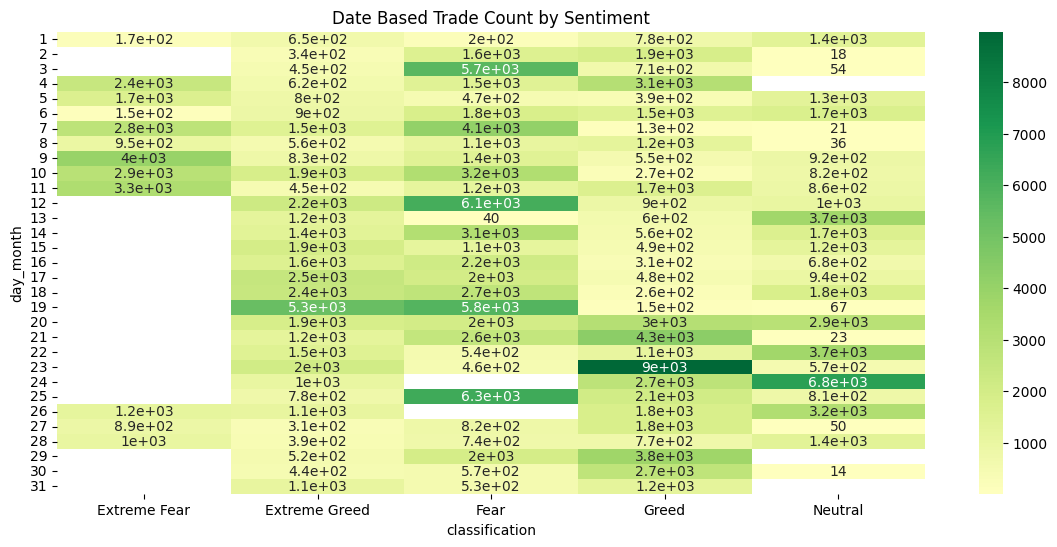

In [4]:
day_trade_count = trade_history.pivot_table(
    values='Trade ID',
    index='day_month',
    columns='classification',
    aggfunc='count'
)

# week_trade_count

plt.figure(figsize=(14,6))

sns.heatmap(
    day_trade_count,
    cmap='RdYlGn',
    center=0,
    annot=True
)

plt.title("Date Based Trade Count by Sentiment")

# Key Insights: Date-Based Trade Count by Sentiment

## Fear
- Dominated trading activity across most dates.
- Highest activity:
  - `12` → **6.1K trades**
  - `25` → **6.3K trades**
  - `19` → **5.8K trades**

## Greed
- Peak trading participation:
  - `23` → **9.0K trades** (highest overall)
  - `03` → **7.1K trades**
  - `28` → **7.7K trades**

## Extreme Greed
- Highest activity occurred on:
  - `19` → **5.3K trades**
  - `03` → **4.5K trades**

## Neutral
- Significant spikes observed on:
  - `24` → **6.8K trades**
  - `13` → **3.7K trades**
  - `22` → **3.7K trades**

## Extreme Fear
- Generally showed the lowest participation levels.
- Highest activity:
  - `11` → **3.3K trades**
  - `10` → **2.9K trades**

- Fear and Greed regimes consistently generated the highest market participation throughout the month.
- Large trade-count spikes frequently aligned with highly volatile sentiment regimes, particularly Greed-related periods.

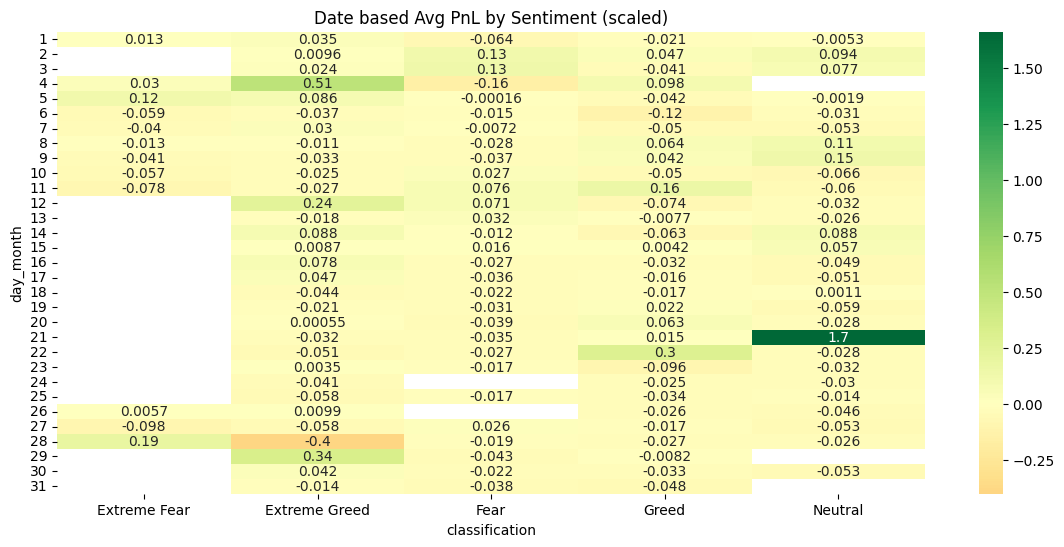

In [5]:
day_profit_pivot = trade_history.pivot_table(
    values='Scaled PnL',
    index='day_month',
    columns='classification',
    aggfunc='mean'
)

plt.figure(figsize=(14,6))

sns.heatmap(
    day_profit_pivot,
    cmap='RdYlGn',
    center=0,
    annot=True
)

plt.title("Date based Avg PnL by Sentiment (scaled)")
plt.show()

# Key Insights: Date-Based Avg PnL by Sentiment

## Extreme Fear
- Highest profitability:
  - `28` → **0.19 scaled avg pnl**
  - `05` → **0.12**
- Weakest period:
  - `27` → **-0.098**

## Extreme Greed
- Strongest profitability occurred on:
  - `04` → **0.51 scaled avg pnl**
  - `29` → **0.34**
  - `22` → **0.30**
- Largest loss:
  - `28` → **-0.40**

## Fear
- Peak profitability:
  - `02` & `03` → **0.13**
- Weakest performance:
  - `04` → **-0.16**

## Greed
- Best-performing period:
  - `22` → **0.30**
  - `11` → **0.16**
- Weakest periods:
  - `06` → **-0.12**
  - `23` → **-0.096**

## Neutral
- `21` showed the highest profitability across all regimes:
  - **1.70 scaled avg pnl**
- Strong additional performance:
  - `09` → **0.15**
  - `08` → **0.11**
- Weakest periods:
  - `10` → **-0.066**
  - `19` → **-0.059**

- Extreme Greed and Neutral sentiment exhibited the highest pnl volatility across monthly trading periods.
- Fear-related profitability remained comparatively stable throughout the month.